# Dataset Explorer
Interactive exploration of the BC dataset v4

# Dataset Explorer — bc_dataset_v4

**What's new in v4:**
- kv range corrected via `brentq`: only kv ∈ [KV_MIN, KV_MAX] that maps to [9.0, 15.5] bar
- References stay strictly within operating bounds (no clipping needed)
- Trajectory modes: step (40%) + ramp (40%) + burst (20%)
- Future-aware NMPC: looks ahead full N_PRED horizon

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Load dataset v6
data_dir = os.path.join(os.path.abspath(''), '..', 'data')
data = np.load(os.path.join(data_dir, 'bc_dataset_v6.npz'))
print("Loaded: bc_dataset_v6.npz")

p_c     = data['p_c']     / 1e5   # Pa → bar
p_c_ref = data['p_c_ref'] / 1e5   # Pa → bar
kv_prev = data['kv_prev']
kv_set  = data['kv_set']

steps_per_ep = 80
n_episodes   = len(p_c) // steps_per_ep

print(f"Total samples:    {len(p_c)}")
print(f"Episodes:         {n_episodes}")
print(f"Steps/episode:    {steps_per_ep}")
print(f"p_c  range:       [{p_c.min():.2f}, {p_c.max():.2f}] bar")
print(f"p_ref range:      [{p_c_ref.min():.2f}, {p_c_ref.max():.2f}] bar")
print(f"kv_set range:     [{kv_set.min():.3f}, {kv_set.max():.3f}]")
print(f"kv_sat (>0.99):   {(kv_set>0.99).sum()} steps ({100*(kv_set>0.99).mean():.1f}%)")
error = p_c_ref - p_c
print(f"Tracking error:   mean={error.mean():.3f}, std={error.std():.3f} bar")

## 1. Browse Individual Episodes
Change `ep` to explore different episodes

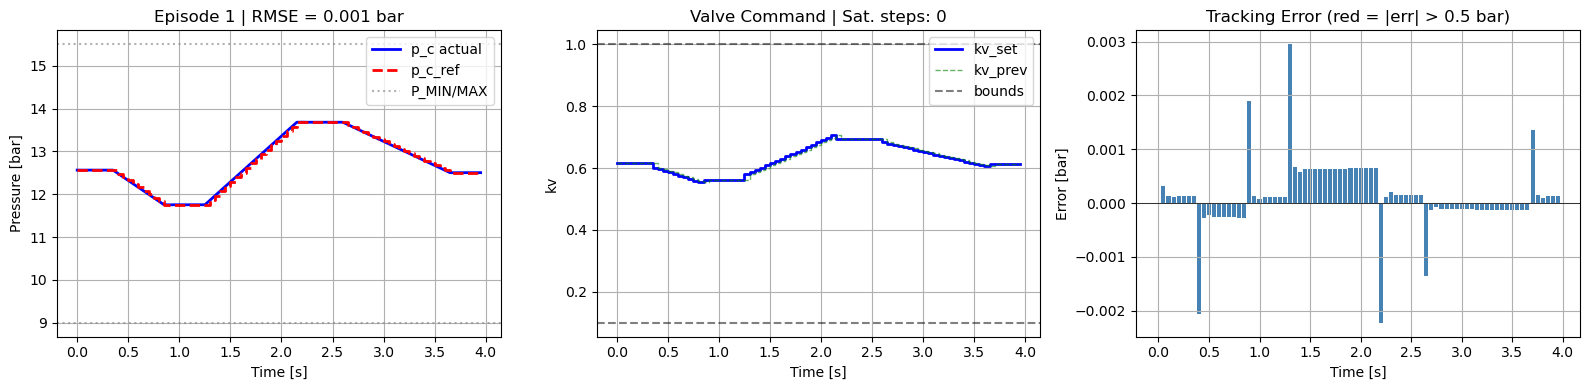

In [2]:
ep = 0  # <-- CHANGE THIS to browse episodes (0 to n_episodes-1)

s = ep * steps_per_ep
e = s + steps_per_ep
t = np.arange(steps_per_ep) * 0.05   # 0 to 4s

err      = p_c_ref[s:e] - p_c[s:e]
rmse     = np.sqrt(np.mean(err**2))
saturated = (kv_set[s:e] > 0.99).sum()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(t, p_c[s:e], 'b-', lw=2, label='p_c actual')
axes[0].step(t, p_c_ref[s:e], 'r--', lw=2, label='p_c_ref', where='post')
axes[0].axhline(9.0,  c='gray', ls=':', alpha=0.6, label='P_MIN/MAX')
axes[0].axhline(15.5, c='gray', ls=':', alpha=0.6)
axes[0].set_xlabel('Time [s]')
axes[0].set_ylabel('Pressure [bar]')
axes[0].set_title(f'Episode {ep+1} | RMSE = {rmse:.3f} bar')
axes[0].legend()
axes[0].grid(True)

axes[1].step(t, kv_set[s:e], 'b-', lw=2, where='post', label='kv_set')
axes[1].step(t, kv_prev[s:e], 'g--', lw=1, where='post', label='kv_prev', alpha=0.6)
axes[1].axhline(1.0, ls='--', c='k', alpha=0.5, label='bounds')
axes[1].axhline(0.1, ls='--', c='k', alpha=0.5)
axes[1].set_xlabel('Time [s]')
axes[1].set_ylabel('kv')
axes[1].set_title(f'Valve Command | Sat. steps: {saturated}')
axes[1].legend()
axes[1].grid(True)

bar_colors = ['red' if abs(v) > 0.5 else 'steelblue' for v in err]
axes[2].bar(t, err, width=0.04, color=bar_colors)
axes[2].axhline(0, c='k', lw=0.5)
axes[2].set_xlabel('Time [s]')
axes[2].set_ylabel('Error [bar]')
axes[2].set_title('Tracking Error (red = |err| > 0.5 bar)')
axes[2].grid(True)

plt.tight_layout()
plt.show()

## 2. Dataset Overview

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

axes[0,0].hist(p_c, bins=50, edgecolor='black')
axes[0,0].set_xlabel('p_c [bar]', fontsize=13)
axes[0,0].set_ylabel('Count', fontsize=13)
axes[0,0].set_title('Chamber Pressure Distribution', fontsize=14)
axes[0,0].tick_params(labelsize=12)

axes[0,1].hist(p_c_ref, bins=50, edgecolor='black', color='orange')
axes[0,1].axvline(9.0,  c='r', ls='--', lw=2, label='P_MIN=9.0')
axes[0,1].axvline(15.5, c='g', ls='--', lw=2, label='P_MAX=15.5')
axes[0,1].set_xlabel('p_c_ref [bar]', fontsize=13)
axes[0,1].set_ylabel('Count', fontsize=13)
axes[0,1].set_title('Reference Pressure Distribution', fontsize=14)
axes[0,1].tick_params(labelsize=12)
axes[0,1].legend(fontsize=11)

error = p_c_ref - p_c
axes[0,2].hist(error, bins=50, edgecolor='black', color='green')
axes[0,2].axvline(0, c='r', ls='--', lw=2)
axes[0,2].set_xlabel('Tracking Error [bar]', fontsize=13)
axes[0,2].set_ylabel('Count', fontsize=13)
axes[0,2].set_title(f'Error Distribution (std={error.std():.3f} bar)', fontsize=14)
axes[0,2].tick_params(labelsize=12)

axes[1,0].hist(kv_set, bins=50, edgecolor='black', color='steelblue')
axes[1,0].axvline(1.0, c='r', ls='--', lw=2, label='saturation')
axes[1,0].axvline(0.1, c='r', ls='--', lw=2)
axes[1,0].set_xlabel('kv_set', fontsize=13)
axes[1,0].set_ylabel('Count', fontsize=13)
axes[1,0].set_title(f'Valve Command ({(kv_set>0.99).sum()} steps at saturation)', fontsize=14)
axes[1,0].tick_params(labelsize=12)
axes[1,0].legend(fontsize=11)

dkv = kv_set - kv_prev
axes[1,1].hist(dkv, bins=50, edgecolor='black', color='purple')
axes[1,1].axvline(0, c='r', ls='--', lw=1)
trivial = (np.abs(dkv) < 0.02).sum()
axes[1,1].set_xlabel('kv_set - kv_prev', fontsize=13)
axes[1,1].set_ylabel('Count', fontsize=13)
axes[1,1].set_title(f'Valve Change ({trivial}/{len(dkv)} = {100*trivial/len(dkv):.0f}% trivial <0.02)', fontsize=14)
axes[1,1].tick_params(labelsize=12)

axes[1,2].scatter(error, dkv, alpha=0.3, s=5, c='steelblue')
axes[1,2].axhline(0, c='r', ls='--', alpha=0.5)
axes[1,2].axvline(0, c='r', ls='--', alpha=0.5)
axes[1,2].set_xlabel('Tracking Error [bar]', fontsize=13)
axes[1,2].set_ylabel('Δkv', fontsize=13)
axes[1,2].set_title('Error vs Valve Change\n(should show correlation)', fontsize=14)
axes[1,2].tick_params(labelsize=12)

plt.tight_layout()

plots_dir = os.path.join(os.path.abspath(''), '..', 'results', 'plots')
os.makedirs(plots_dir, exist_ok=True)
plt.savefig(os.path.join(plots_dir, 'data_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

## 3. Episode Quality Summary
Green = good episode, Red = bad episode (NMPC struggling)

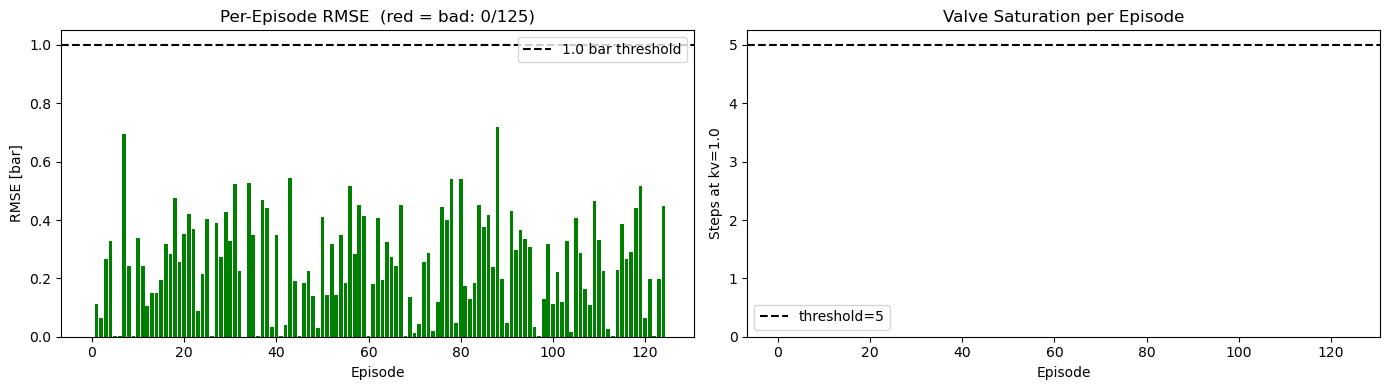

Good episodes: 125 / 125
Bad episodes:  0 / 125
Mean RMSE:     0.247 bar
Max RMSE:      0.718 bar


In [4]:
rmses      = []
sat_counts = []

for ep in range(n_episodes):
    s = ep * steps_per_ep
    e = s + steps_per_ep
    err = p_c_ref[s:e] - p_c[s:e]
    rmses.append(np.sqrt(np.mean(err**2)))
    sat_counts.append((kv_set[s:e] > 0.99).sum())

rmses      = np.array(rmses)
sat_counts = np.array(sat_counts)

# Threshold: 1.0 bar — episodes with RMSE above this indicate poor NMPC tracking
# Saturation (kv=1.0 sustained) also flags bad episodes
is_bad = (rmses > 1.0) | (sat_counts > 5)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

colors = ['red' if b else 'green' for b in is_bad]
axes[0].bar(range(n_episodes), rmses, color=colors)
axes[0].axhline(1.0, c='k', ls='--', label='1.0 bar threshold')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('RMSE [bar]')
axes[0].set_title(f'Per-Episode RMSE  (red = bad: {is_bad.sum()}/{n_episodes})')
axes[0].legend()

axes[1].bar(range(n_episodes), sat_counts, color=colors)
axes[1].axhline(5, c='k', ls='--', label='threshold=5')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Steps at kv=1.0')
axes[1].set_title('Valve Saturation per Episode')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Good episodes: {(~is_bad).sum()} / {n_episodes}")
print(f"Bad episodes:  {is_bad.sum()} / {n_episodes}")
print(f"Mean RMSE:     {rmses.mean():.3f} bar")
print(f"Max RMSE:      {rmses.max():.3f} bar")

## 4. The "kv_set ≈ kv_prev" Problem
Shows how trivial most of the mapping is

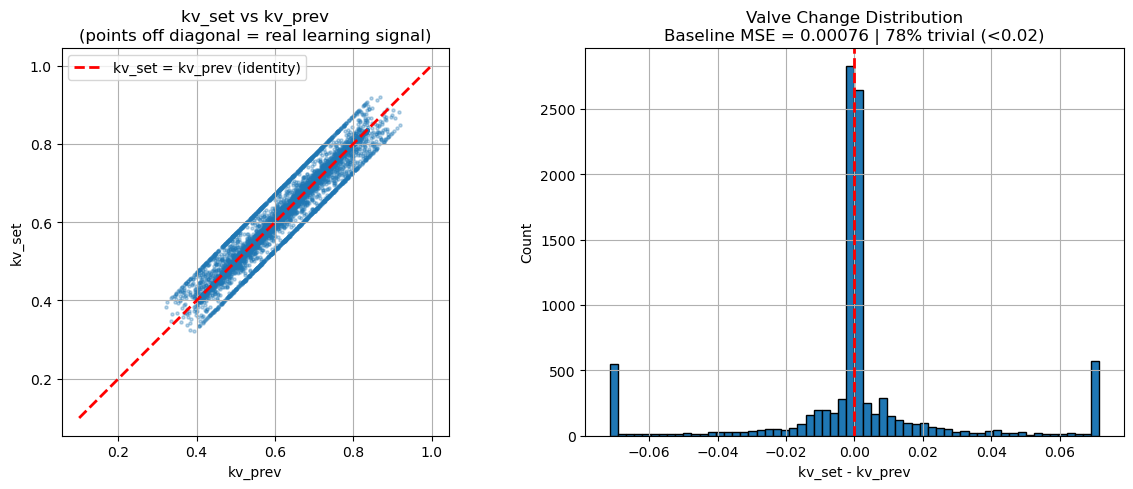

Baseline MSE (predict kv_prev): 0.000760
Trivial steps (|Δkv| < 0.02):  78.3%
Active steps  (|Δkv| >= 0.02): 21.7%


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(kv_prev, kv_set, alpha=0.3, s=5)
axes[0].plot([0.1, 1.0], [0.1, 1.0], 'r--', lw=2, label='kv_set = kv_prev (identity)')
axes[0].set_xlabel('kv_prev')
axes[0].set_ylabel('kv_set')
axes[0].set_title('kv_set vs kv_prev\n(points off diagonal = real learning signal)')
axes[0].legend()
axes[0].grid(True)
axes[0].set_aspect('equal')

baseline_mse = np.mean((kv_set - kv_prev)**2)
dkv = kv_set - kv_prev
trivial_pct  = 100 * (np.abs(dkv) < 0.02).sum() / len(dkv)

axes[1].hist(dkv, bins=60, edgecolor='black')
axes[1].axvline(0, c='r', ls='--', lw=2)
axes[1].set_xlabel('kv_set - kv_prev')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Valve Change Distribution\n'
                  f'Baseline MSE = {baseline_mse:.5f} | {trivial_pct:.0f}% trivial (<0.02)')
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"Baseline MSE (predict kv_prev): {baseline_mse:.6f}")
print(f"Trivial steps (|Δkv| < 0.02):  {trivial_pct:.1f}%")
print(f"Active steps  (|Δkv| >= 0.02): {100-trivial_pct:.1f}%")